# CLASSIFICATION

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, classification_report, precision_score,
                             recall_score, f1_score, roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB, ComplementNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [36]:
df = pd.read_csv('finale01_preprocessed.csv')

In [37]:
df

,Name,YearPublished,GameWeight,MinPlayers,MaxPlayers,ComAgeRec,InterestScore,NumWeightVotes,log_NumWeightVotes,PlaytimeComAvg,...,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating,InterestScore_log
0,Assassin's Creed: Arena,2014,1.8333,2,4,8.0,199.333333,6,1.945910,30.0,...,0,0,0,0,0,0,0,0,1,5.299983
1,Bag of Chips,2021,1.0000,2,5,8.0,43.666667,6,1.945910,17.5,...,0,0,0,0,0,0,0,0,2,3.799228
2,Gùgōng: Deluxe Big Box,2020,3.6667,1,5,10.0,311.333333,9,2.302585,90.0,...,0,0,0,0,0,0,0,0,3,5.744071
3,LetterFlip,2004,1.3077,2,2,7.0,54.333333,13,2.639057,20.0,...,0,0,0,0,0,0,0,0,1,4.013375
4,Treasures of Cibola,2019,1.5000,2,4,10.0,82.333333,2,1.098612,17.5,...,0,0,0,0,0,0,0,0,2,4.422849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21239,Ballast,1998,1.0000,2,4,8.0,40.333333,4,1.609438,15.0,...,0,0,0,0,0,0,0,0,1,3.721669
21240,Leapfrog,2004,1.5000,1,6,6.0,104.666667,16,2.833213,20.0,...,0,0,0,0,0,0,0,0,2,4.660289
21241,Athos,1993,1.6667,2,4,11.0,82.666667,3,1.386294,45.0,...,0,0,0,0,0,0,0,0,1,4.426841
21242,Hoplomachus: Origins,2015,3.0370,1,2,13.8,634.333333,27,3.332205,22.5,...,0,1,0,0,0,0,0,0,3,6.454150


In [38]:
# Droppa name da df
df = df.drop(columns=['Name'])


In [39]:
# Droppa NumWeightVotes, NumUserRatings, NumAlternates, NumExpansions, NumImplementations
df = df.drop(columns=['NumWeightVotes', 'NumUserRatings', 'NumAlternates', 'NumExpansions', 'NumImplementations'])

In [40]:
# Prendi   'log_NumUserRatings','log_NumWeightVotes', 'NumExpansions_log','NumAlternates_log', 'NumImplementations_log' e togli il log dal nome
df = df.rename(columns={
    'log_NumUserRatings': 'NumUserRatings',
    'log_NumWeightVotes': 'NumWeightVotes',
    'NumExpansions_log': 'NumExpansions',
    'NumAlternates_log': 'NumAlternates',
    'NumImplementations_log': 'NumImplementations'
})


Non prendo in considerazione Name, NumWeightVotes, NumUserRatings, NumAlternates, NumExpansions, NumImplementations ma solo le loro versioni log

# First target: RATING (Multiclass classification)

In [41]:
# Separo input (X) e target (y)
X = df.drop(columns=['Rating'])
y = df['Rating']


In [42]:
# Splitto in train e test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,          # 80/20 
    stratify=y,             
    random_state=42
)


In [43]:
# Controllo il bilanciamento del train 
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

# - Low → 1


# - Medium → 2


# - High → 3


Rating
2    7526
1    5513
3    3956
Name: count, dtype: int64
Rating
2    44.283613
1    32.438953
3    23.277435
Name: proportion, dtype: float64


In [45]:
df_train_corr = X_train.copy()
df_train_corr['Rating'] = y_train

correlation_rating = df_train_corr.corr()['Rating'].drop('Rating')
print(correlation_rating.sort_values(ascending=False))


GameWeight            0.474321
InterestScore_log     0.360864
YearPublished         0.349787
NumExpansions         0.309776
NumUserRatings        0.290132
InterestScore         0.280779
ComAgeRec             0.276193
PlaytimeComAvg        0.255290
NumWeightVotes        0.234566
Cat:Strategy          0.212322
Kickstarted           0.201917
Cat:War               0.178712
NumImplementations    0.146481
IsReimplementation    0.135112
Cat:Thematic          0.086216
Cat:Family           -0.001621
Cat:CGS              -0.011726
NumAlternates        -0.018681
Cat:Party            -0.024745
Cat:Abstract         -0.048396
MaxPlayers           -0.157311
Cat:Childrens        -0.165808
MinPlayers           -0.182252
Name: Rating, dtype: float64


| Feature                       | Interpretazione                        |
| ----------------------------- | -------------------------------------- |
| **GameWeight (0.47)**         | Giochi più complessi → rating più alto |
| **YearPublished (0.35)**      | Giochi più recenti → rating più alto   |
| **NumExpansions_log (0.31)**  | Giochi “espandibili” → più apprezzati  |
| **log_NumUserRatings (0.29)** | Più voti → maggiore apprezzamento      |
| **InterestScore (0.28)**      | Interesse generale coerente            |
| **ComAgeRec (0.28)**          | Target più adulto → rating più alto    |


In [46]:
num_features = [
    'GameWeight',
    'YearPublished',
    'PlaytimeComAvg',
    'ComAgeRec',
    'InterestScore',
    'MinPlayers',
    'MaxPlayers',
    'NumUserRatings',
    'NumWeightVotes',
    'NumExpansions',
    'NumAlternates',
    'NumImplementations'
]

bin_features = [
    'IsReimplementation',
    'Kickstarted',
    'Cat:Strategy',
    'Cat:War',
    'Cat:Thematic',
    'Cat:Family',
    'Cat:CGS',
    'Cat:Abstract',
    'Cat:Party',
    'Cat:Childrens'
]

#from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled_num = scaler.fit_transform(X_train[num_features])
X_test_scaled_num = scaler.transform(X_test[num_features])

import pandas as pd

X_train_scaled = pd.DataFrame(
    X_train_scaled_num,
    columns=num_features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_num,
    columns=num_features,
    index=X_test.index
)

# Aggiungi le feature binarie
X_train_scaled = pd.concat([X_train_scaled, X_train[bin_features]], axis=1)
X_test_scaled = pd.concat([X_test_scaled, X_test[bin_features]], axis=1)
#print(X_train_scaled.head())


- Varianza delle feature: più è bassa meno sono informative (però accuracy e gli altri valori scendevano, per cui ho scartato questa opzione)

In [47]:
from sklearn.feature_selection import VarianceThreshold

# Features con varianza molto bassa sono inutili
variances = X_train_scaled.var().sort_values()
print(variances.head(10))  # Le 10 con varianza più bassa

Cat:CGS               0.013294
Cat:Party             0.026836
Cat:Childrens         0.037220
Cat:Abstract          0.044753
Cat:Thematic          0.053925
Cat:Family            0.094609
Cat:Strategy          0.098298
IsReimplementation    0.104019
Kickstarted           0.131258
Cat:War               0.137461
dtype: float64


,YearPublished,GameWeight,MinPlayers,MaxPlayers,ComAgeRec,InterestScore,NumWeightVotes,PlaytimeComAvg,NumUserRatings,NumAlternates,...,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating,InterestScore_log
YearPublished,1.000000,-0.003402,-0.159325,0.054841,-0.068924,0.117453,-0.251051,-0.156959,0.058034,-0.070265,...,-0.012026,0.023722,-0.264026,-0.024883,-0.055631,-0.147773,-0.015403,-0.154720,0.419610,0.117453
GameWeight,-0.003402,1.000000,-0.192612,-0.290767,0.623429,0.256646,0.287458,0.695507,0.142288,-0.176409,...,0.141533,0.303153,0.442680,-0.152621,0.069315,-0.012329,-0.156464,-0.244231,0.471889,0.256646
MinPlayers,-0.159325,-0.192612,1.000000,0.313769,-0.076201,-0.098713,-0.052828,-0.089785,-0.031742,0.031946,...,-0.087784,0.003539,-0.145327,0.021754,-0.010330,-0.015053,0.157661,-0.002525,-0.213695,-0.098713
MaxPlayers,0.054841,-0.290767,0.313769,1.000000,-0.174652,-0.008039,-0.065551,-0.109253,0.071758,0.091331,...,0.038211,0.004065,-0.382804,0.075247,-0.059065,-0.147844,0.196236,0.009732,-0.176014,-0.008039
ComAgeRec,-0.068924,0.623429,-0.076201,-0.174652,1.000000,0.100306,0.132444,0.608029,-0.021682,-0.223123,...,0.112949,0.174229,0.535939,-0.263853,0.045003,-0.173391,-0.040947,-0.314693,0.276265,0.100306
InterestScore,0.117453,0.256646,-0.098713,-0.008039,0.100306,1.000000,0.780198,0.199111,0.933212,0.305461,...,0.249014,0.368263,0.008430,0.317399,0.028505,-0.047358,0.169099,-0.052133,0.336853,1.000000
NumWeightVotes,-0.251051,0.287458,-0.052828,-0.065551,0.132444,0.780198,1.000000,0.255941,0.822228,0.283644,...,0.255448,0.397482,0.142169,0.346445,0.064087,0.031221,0.155272,0.008153,0.207912,0.780198
PlaytimeComAvg,-0.156959,0.695507,-0.089785,-0.109253,0.608029,0.199111,0.255941,1.000000,0.090150,-0.166051,...,0.150384,0.209071,0.482132,-0.128152,-0.009459,-0.162112,-0.102868,-0.204491,0.295208,0.199111
NumUserRatings,0.058034,0.142288,-0.031742,0.071758,-0.021682,0.933212,0.822228,0.090150,1.000000,0.348859,...,0.248587,0.385057,-0.121432,0.359755,0.045121,-0.006399,0.183888,-0.013495,0.248363,0.933212
NumAlternates,-0.070265,-0.176409,0.031946,0.091331,-0.223123,0.305461,0.283644,-0.166051,0.348859,1.000000,...,0.060829,0.081982,-0.164227,0.225139,0.003143,0.043294,0.140527,0.198655,-0.024649,0.305461


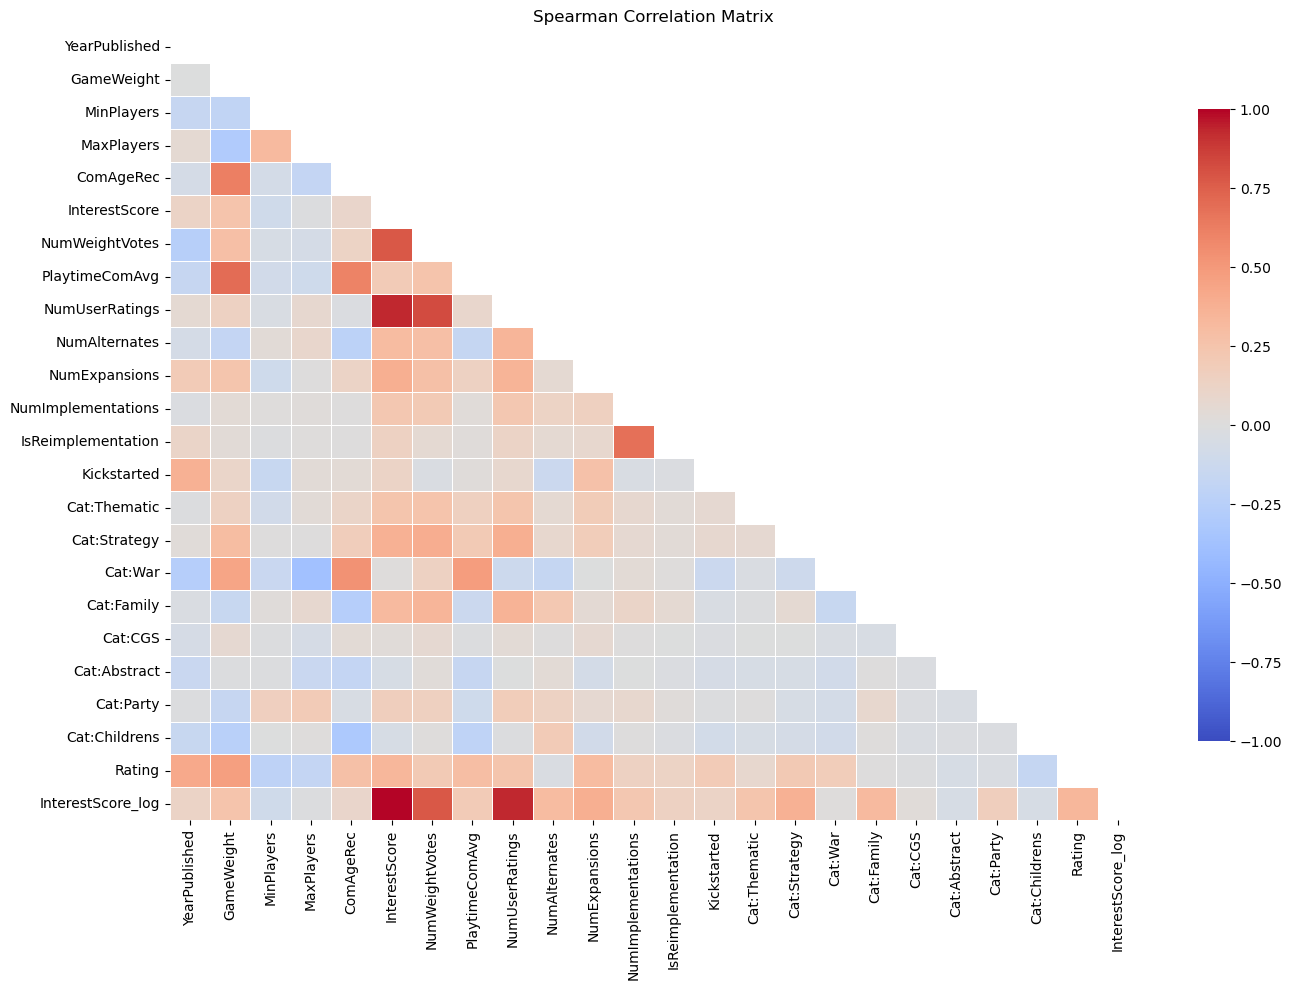

,col_A,col_B,rho,abs_rho,missing_A_%,missing_B_%,card_A,card_B
3,InterestScore,InterestScore_log,1.000000,1.000000,0.0,0.0,4345,4345
2,InterestScore,NumUserRatings,0.933212,0.933212,0.0,0.0,4345,3084
6,NumUserRatings,InterestScore_log,0.933212,0.933212,0.0,0.0,3084,4345
4,NumWeightVotes,NumUserRatings,0.822228,0.822228,0.0,0.0,756,3084
1,InterestScore,NumWeightVotes,0.780198,0.780198,0.0,0.0,4345,756
5,NumWeightVotes,InterestScore_log,0.780198,0.780198,0.0,0.0,756,4345
0,GameWeight,PlaytimeComAvg,0.695507,0.695507,0.0,0.0,3839,134
7,NumImplementations,IsReimplementation,0.680392,0.680392,0.0,0.0,4,2


These columns are highly correlated (|rho| ≥ 0.66).
→ Review each pair and choose which column to keep based on:
   - semantic interpretability (which one is clearer/useful for analysis),
   - lower missingness (%),
   - fewer anomalies/outliers (see previous step),
   - lower redundancy w.r.t. other variables



In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Funzione principale per calcolare la correlazione di Spearman e gestire le coppie altamente correlate
def spearman_and_redundancy(df, threshold=0.66):
    # Seleziona tutte le colonne numeriche automaticamente
    numerical_vars = df.select_dtypes(include=[np.number]).columns

    # Calcola la matrice di correlazione di Spearman
    spearman_corr = df[numerical_vars].corr(method="spearman")

    # Mostra la matrice numerica per un'analisi precisa
    display(spearman_corr)

    # Crea la maschera per il triangolo superiore
    mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

    # Crea una heatmap per un'ispezione visiva rapida, mascherando il triangolo superiore
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        spearman_corr,
        mask=mask,  # Applica la maschera per nascondere il triangolo superiore
        annot=False,  # Impostato su True se vuoi vedere i numeri, ma può diventare affollato
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
        vmin=-1, vmax=1,  # Scala fissa
        center=0,
        cbar_kws={'shrink': .8}
    )
    plt.title("Spearman Correlation Matrix")
    plt.tight_layout()
    plt.show()

    # Lista per raccogliere le coppie altamente correlate
    high_corr_pairs = []

    # Raccogli le coppie con |rho| ≥ threshold
    rows = []
    for i, a in enumerate(numerical_vars):
        for j, b in enumerate(numerical_vars):
            if j <= i:
                # Considera ogni coppia non ordinata una sola volta; salta la diagonale
                continue
            rho = spearman_corr.loc[a, b]
            if pd.notna(rho) and abs(rho) >= threshold:
                # Calcola altre metriche utili per la scelta manuale successiva
                miss_a = df[a].isna().mean()
                miss_b = df[b].isna().mean()
                card_a = df[a].nunique(dropna=True)
                card_b = df[b].nunique(dropna=True)

                rows.append({
                    "col_A": a,
                    "col_B": b,
                    "rho": float(rho),
                    "abs_rho": float(abs(rho)),
                    "missing_A_%": round(100*miss_a, 2),
                    "missing_B_%": round(100*miss_b, 2),
                    "card_A": int(card_a),
                    "card_B": int(card_b)
                })

    # Se ci sono coppie altamente correlate, mostra un report
    if rows:
        report = pd.DataFrame(rows).sort_values("abs_rho", ascending=False)
        display(report)

        print(
            "These columns are highly correlated (|rho| ≥ {:.2f}).\n"
            "→ Review each pair and choose which column to keep based on:\n"
            "   - semantic interpretability (which one is clearer/useful for analysis),\n"
            "   - lower missingness (%),\n"
            "   - fewer anomalies/outliers (see previous step),\n"
            "   - lower redundancy w.r.t. other variables\n".format(threshold)
        )

        # Se vuoi prendere decisioni ora, costruisci una lista come questa:
        # to_drop_manual = ['ComMaxPlaytime', 'NumUserRatings', 'NumWish']  # esempio
        # df = df.drop(columns=to_drop_manual)
        # numerical_vars = [c for c in numerical_vars if c not in to_drop_manual]

    else:
        print(f"No pairs with |rho| ≥ {threshold:.2f}.")

# Esegui la funzione
spearman_and_redundancy(df)


In [50]:
print(correlation_rating[['InterestScore', 'NumUserRatings', 'NumWeightVotes']])

InterestScore     0.280779
NumUserRatings    0.290132
NumWeightVotes    0.234566
Name: Rating, dtype: float64


# KNN

In [51]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# # Trova le K migliori features
# # Solo per vedere quali features sono importanti
selector = SelectKBest(score_func=mutual_info_classif, k=12)
selector.fit(X_train_scaled, y_train)  # solo train
selected_features = X_train_scaled.columns[selector.get_support()]
print(selected_features)

# # Poi copi manualmente in selected_columns

Index(['GameWeight', 'YearPublished', 'PlaytimeComAvg', 'ComAgeRec',
       'InterestScore', 'MinPlayers', 'NumUserRatings', 'NumWeightVotes',
       'NumExpansions', 'Kickstarted', 'Cat:Strategy', 'Cat:Childrens'],
      dtype='object')


Utilizzando le features selezionate con MI ho i seguenti risultati:  
📊 RISULTATI KNN
Accuracy: 0.6557

Macro average:
  Precision: 0.6688
  Recall:    0.6477
  F1-score:  0.6563

Weighted average:
  Precision: 0.6593
  Recall:    0.6557
  F1-score:  0.6558

In [52]:
# Subset di feature per KNN (selezionate manualmente)
selected_columns = [
    'GameWeight',
    'YearPublished',
    'ComAgeRec',
    'InterestScore',
    'MinPlayers',
    'MaxPlayers',
    'NumUserRatings',
    'NumExpansions',
    'IsReimplementation',
    'Cat:Strategy',
    'Cat:War',
    'Cat:Abstract'
]

# Feature scartate: 

#'PlaytimeComAvg',
#'log_NumWeightVotes', # scartata perché ridondante
#'NumAlternates_log',
#'NumImplementations_log',
#'Kickstarted',
#'Cat:Thematic',
#'Cat:Family',
#'Cat:CGS',
#'Cat:Party',
#'Cat:Childrens'


# (consigliato) filtra solo colonne effettivamente presenti, per evitare KeyError
selected_columns = [c for c in selected_columns if c in X_train_scaled.columns]

# X per KNN
X_train_knn = X_train_scaled[selected_columns]
X_test_knn  = X_test_scaled[selected_columns]

# y per KNN (già separata)
y_train_knn = y_train
y_test_knn  = y_test

print(X_train_knn.shape, X_test_knn.shape)
print(y_train_knn.shape, y_test_knn.shape)

X_train_knn.head()

(16995, 12) (4249, 12)
(16995,) (4249,)


,GameWeight,YearPublished,ComAgeRec,InterestScore,MinPlayers,MaxPlayers,NumUserRatings,NumExpansions,IsReimplementation,Cat:Strategy,Cat:War,Cat:Abstract
10985,-0.550251,0.449504,-0.035552,-0.369630,1.505736,0.140793,-0.705353,-0.492213,0,0,0,0
14546,0.899570,0.924015,-0.035552,-0.203082,-0.007211,0.986145,-0.304651,-0.492213,0,0,0,0
5486,0.164196,0.528589,1.318674,-0.314852,-1.520158,-1.549913,-0.749292,-0.492213,0,0,1,0
12117,-0.256127,0.607674,-0.035552,-0.261181,-0.007211,0.563469,-0.252956,0.527071,0,0,0,0
10185,0.147932,0.765844,0.303004,-0.014955,-0.007211,0.563469,1.063365,-0.492213,0,0,0,0


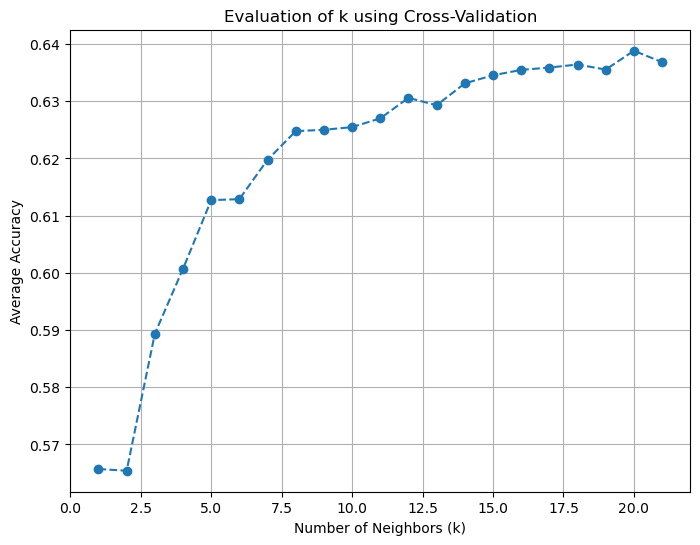

In [16]:
# Search for the best k value
k_values = range(1, 22)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_knn, y_train_knn, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot to visualize k search
plt.figure(figsize=(8, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='--')
plt.title('Evaluation of k using Cross-Validation')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Average Accuracy')
plt.grid()
plt.show()

In [17]:
# Best k value
best_k = k_values[np.argmax(cv_scores)]
print(f"Best k value: {best_k}")

Best k value: 20


Uniform e manhattan danno i migliori risultati (non mettere Distance perché dà un overfitting impressionante di 0.33%)

In [18]:
# Train the model with the best k

knn = KNeighborsClassifier(
        n_neighbors=best_k,
        weights='uniform',  # Example of custom
        metric="manhattan"  # Example of custom
)
knn.fit(X_train_knn, y_train_knn)

y_pred = knn.predict(X_test_knn)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test_knn, y_pred)

precision_macro = precision_score(y_test_knn, y_pred, average='macro', zero_division=0)
recall_macro    = recall_score(y_test_knn, y_pred, average='macro', zero_division=0)
f1_macro        = f1_score(y_test_knn, y_pred, average='macro', zero_division=0)

precision_weighted = precision_score(y_test_knn, y_pred, average='weighted', zero_division=0)
recall_weighted    = recall_score(y_test_knn, y_pred, average='weighted', zero_division=0)
f1_weighted        = f1_score(y_test_knn, y_pred, average='weighted', zero_division=0)

print("📊 RISULTATI KNN")
print(f"Accuracy: {accuracy:.4f}")
print("\nMacro average:")
print(f"  Precision: {precision_macro:.4f}")
print(f"  Recall:    {recall_macro:.4f}")
print(f"  F1-score:  {f1_macro:.4f}")

print("\nWeighted average:")
print(f"  Precision: {precision_weighted:.4f}")
print(f"  Recall:    {recall_weighted:.4f}")
print(f"  F1-score:  {f1_weighted:.4f}")


📊 RISULTATI KNN
Accuracy: 0.6569

Macro average:
  Precision: 0.6716
  Recall:    0.6500
  F1-score:  0.6582

Weighted average:
  Precision: 0.6607
  Recall:    0.6569
  F1-score:  0.6568


In [20]:
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=best_k, weights='uniform', metric='manhattan')
scores = cross_val_score(knn, X_train_knn, y_train_knn, cv=5, scoring='accuracy')
print(f"CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

CV Accuracy: 0.6456 (+/- 0.0064)


In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test_knn, y_pred))

              precision    recall  f1-score   support

           1       0.67      0.70      0.68      1378
           2       0.62      0.66      0.64      1882
           3       0.72      0.59      0.65       989

    accuracy                           0.66      4249
   macro avg       0.67      0.65      0.66      4249
weighted avg       0.66      0.66      0.66      4249



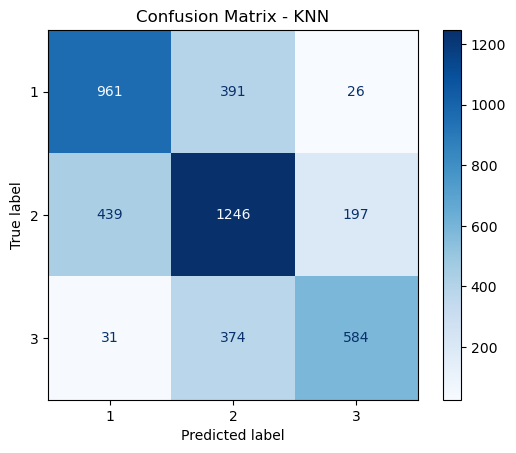

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

# Lascia che lo calcoli automaticamente
ConfusionMatrixDisplay.from_predictions(y_test_knn, y_pred, cmap=plt.cm.Blues)
plt.title('Confusion Matrix - KNN')
plt.show()

In [23]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd
import numpy as np

# Calcola metriche
precision, recall, f1, support = precision_recall_fscore_support(
    y_test_knn, y_pred, labels=[1, 2, 3]
)

# Accuracy per classe (OvR)
class_accuracies = []
for class_label in [1, 2, 3]:
    y_test_binary = (y_test_knn == class_label).astype(int)
    y_pred_binary = (y_pred == class_label).astype(int)
    class_acc = accuracy_score(y_test_binary, y_pred_binary)
    class_accuracies.append(class_acc)

# Overall accuracy
overall_acc = accuracy_score(y_test_knn, y_pred)

# Crea tabella principale (solo le 3 classi)
main_table = pd.DataFrame({
    'Class': ['Low', 'Medium', 'High'],
    'Precision': [f'{p:.2%}' for p in precision],
    'Recall': [f'{r:.2%}' for r in recall],
    'F1-Score': [f'{f:.2%}' for f in f1],
    'Support': support.astype(int)
})

# Tabella medie aggregate
aggregate_table = pd.DataFrame({
    'Metric': ['Macro Average', 'Weighted Average', 'Overall Accuracy'],
    'Precision': [f'{precision.mean():.2%}', 
                  f'{np.average(precision, weights=support):.2%}', 
                  '-'],
    'Recall': [f'{recall.mean():.2%}', 
               f'{np.average(recall, weights=support):.2%}', 
               '-'],
    'F1-Score': [f'{f1.mean():.2%}', 
                 f'{np.average(f1, weights=support):.2%}', 
                 '-'],
    'Value': ['-', '-', f'{overall_acc:.2%}']
})

# Stampa
print("\n" + "━"*75)
print("  K-NEAREST NEIGHBORS CLASSIFICATION REPORT")
print("━"*75)
print("\nTable 1: Per-Class Performance Metrics\n")
print(main_table.to_string(index=False))
print("\n" + "─"*75)
print("\nTable 2: Aggregate Metrics\n")
print(aggregate_table.to_string(index=False))
print("\n" + "━"*75)
print(f"\nDataset: {support.sum():,} samples | Classes: 3 (Low/Medium/High)")
print(f"Algorithm: K-NN (k={best_k}, weights='uniform', metric='manhattan')")
print("━"*75)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  K-NEAREST NEIGHBORS CLASSIFICATION REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Table 1: Per-Class Performance Metrics

 Class Precision Recall F1-Score  Support
   Low    67.16% 69.74%   68.42%     1378
Medium    61.96% 66.21%   64.01%     1882
  High    72.37% 59.05%   65.03%      989

───────────────────────────────────────────────────────────────────────────

Table 2: Aggregate Metrics

          Metric Precision Recall F1-Score  Value
   Macro Average    67.16% 65.00%   65.82%      -
Weighted Average    66.07% 65.69%   65.68%      -
Overall Accuracy         -      -        - 65.69%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Dataset: 4,249 samples | Classes: 3 (Low/Medium/High)
Algorithm: K-NN (k=20, weights='uniform', metric='manhattan')
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


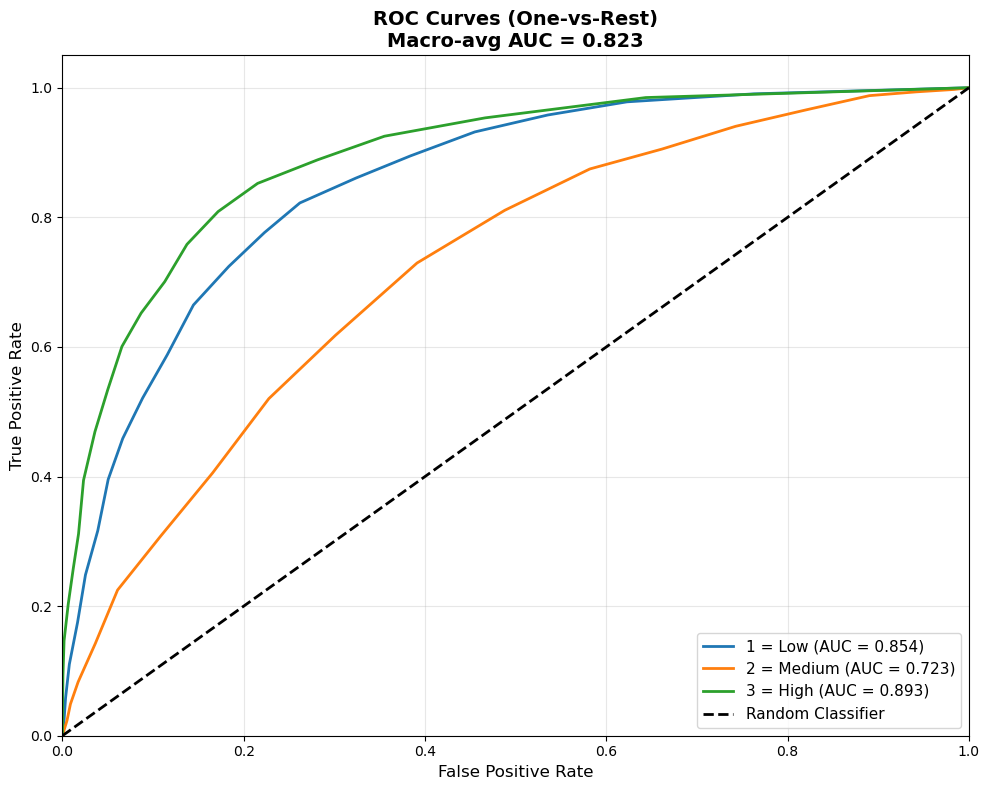


📊 AUC per classe (One-vs-Rest):
  1 = Low : 0.8543
  2 = Medium: 0.7225
  3 = High: 0.8935

🎯 Macro-average AUC: 0.8234


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# 1. FISSA IL MODELLO (se non l'hai già fatto)
knn = KNeighborsClassifier(n_neighbors=best_k, weights='uniform', metric='manhattan')
knn.fit(X_train_knn, y_train_knn)  # ← AGGIUNGI QUESTA RIGA

# 2. Ora puoi procedere
classes = [1, 2, 3]
class_names = {1: "1 = Low", 2: "2 = Medium", 3: "3 = High"}

# Binarizzazione
y_test_bin = label_binarize(y_test_knn, classes=classes)

# Probabilità
y_score = knn.predict_proba(X_test_knn)

# Calcola ROC
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i, c in enumerate(classes):
    idx = np.where(knn.classes_ == c)[0][0]
    fpr[c], tpr[c], _ = roc_curve(y_test_bin[:, i], y_score[:, idx])
    roc_auc[c] = auc(fpr[c], tpr[c])
    plt.plot(fpr[c], tpr[c], lw=2, 
             label=f"{class_names[c]} (AUC = {roc_auc[c]:.3f})")

# Macro-average AUC
macro_auc = float(np.mean(list(roc_auc.values())))

# Linea casuale
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f"ROC Curves (One-vs-Rest)\nMacro-avg AUC = {macro_auc:.3f}", 
          fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 AUC per classe (One-vs-Rest):")
for c in classes:
    print(f"  {class_names[c]:8s}: {roc_auc[c]:.4f}")
print(f"\n🎯 Macro-average AUC: {macro_auc:.4f}")

In [25]:
print("="*60)
print("🔍 KNN OVERFITTING ANALYSIS")
print("="*60)
print(f"Best k:             {best_k}")
print(f"Weights:            uniform")
print(f"Metric:             manhattan")

# Train accuracy
y_train_pred = knn.predict(X_train_knn)
train_acc = accuracy_score(y_train_knn, y_train_pred)

# Test accuracy (già calcolato)
test_acc = accuracy_score(y_test_knn, y_pred)

print(f"\nTrain Accuracy:     {train_acc:.4f}")
print(f"Test Accuracy:      {test_acc:.4f}")
print(f"Overfitting Gap:    {(train_acc - test_acc)*100:+.2f}%")

if train_acc == 1.0:
    print("\n⚠️ WARNING: Perfect training accuracy detected!")
    print("This should NOT happen with k=20. Check for data leakage.")

🔍 KNN OVERFITTING ANALYSIS
Best k:             20
Weights:            uniform
Metric:             manhattan

Train Accuracy:     0.6796
Test Accuracy:      0.6569
Overfitting Gap:    +2.27%


Minimal overfitting gap: +2.27%

# NAIVE-BAYES CLASSIFIER

### GaussianNB e CategoricalNB = Categorical performa meglio!  
Lavora su feature categoriche: discretizza automaticamente le feature numeriche continue usando KBinsDiscretizer. Accuracy CategoricalNB = 58.46% VS Accuracy GaussianNB = 52.46%

In [26]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# ══════════════════════════════════════════════════════════════
# CATEGORICAL NAIVE BAYES - stesso subset del KNN (12 feature)
# ══════════════════════════════════════════════════════════════

# 1) Subset identico a KNN
selected_columns = [
    'GameWeight',
    'YearPublished',
    'ComAgeRec',
    'InterestScore',
    'MinPlayers',
    'MaxPlayers',
    'NumUserRatings',
    'NumExpansions',
    'IsReimplementation',
    'Cat:Strategy',
    'Cat:War',
    'Cat:Abstract'
]

# Filtra solo quelle effettivamente presenti (usa X_train/X_test, non scaled)
selected_columns = [c for c in selected_columns if c in X_train.columns and c in X_test.columns]

# 2) Separa numeriche vs binarie SOLO all'interno del subset
# (aggiusta qui se qualche tua feature "binaria" in realtà non è 0/1)
num_features_cnb = [
    'GameWeight',
    'YearPublished',
    'ComAgeRec',
    'InterestScore',
    'MinPlayers',
    'MaxPlayers',
    'NumUserRatings',
    'NumExpansions'
]
bin_features_cnb = [
    'IsReimplementation',
    'Cat:Strategy',
    'Cat:War',
    'Cat:Abstract'
]

# Tieni solo quelle presenti davvero (robustezza)
num_features_cnb = [c for c in num_features_cnb if c in selected_columns]
bin_features_cnb = [c for c in bin_features_cnb if c in selected_columns]

# 3) Discretizza SOLO numeriche (in 10 bin, ordinali 0..9)
discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')

X_train_disc = discretizer.fit_transform(X_train[num_features_cnb])
X_test_disc  = discretizer.transform(X_test[num_features_cnb])

X_train_cnb = pd.DataFrame(X_train_disc, columns=num_features_cnb, index=X_train.index)
X_test_cnb  = pd.DataFrame(X_test_disc,  columns=num_features_cnb, index=X_test.index)

# 4) Aggiungi binarie (già categoriche: 0/1)
if len(bin_features_cnb) > 0:
    X_train_cnb = pd.concat([X_train_cnb, X_train[bin_features_cnb]], axis=1)
    X_test_cnb  = pd.concat([X_test_cnb,  X_test[bin_features_cnb]], axis=1)

# 5) Riordina le colonne per essere IDENTICHE e nello stesso ordine del subset KNN
final_cols = [c for c in selected_columns if c in X_train_cnb.columns]
X_train_cnb = X_train_cnb[final_cols]
X_test_cnb  = X_test_cnb[final_cols]

# 6) Assicurati interi non negativi (CategoricalNB requirement)
X_train_cnb = X_train_cnb.astype(int)
X_test_cnb  = X_test_cnb.astype(int)

print("✅ Features preparate per CategoricalNB (stesso subset del KNN)")
print(f"Columns used ({len(final_cols)}): {final_cols}")
print(f"Shape train: {X_train_cnb.shape}")
print(f"Shape test:  {X_test_cnb.shape}")
print("\nRange valori (dopo discretizzazione):")
print(f"Min: {X_train_cnb.min().min()}")
print(f"Max: {X_train_cnb.max().max()}")
print("\nEsempio prima riga:")
print(X_train_cnb.head(1))

# ══════════════════════════════════════════════════════════════
# MODELLO CATEGORICAL NAIVE BAYES
# ══════════════════════════════════════════════════════════════

cnb = CategoricalNB()
cnb.fit(X_train_cnb, y_train)

y_pred_cnb = cnb.predict(X_test_cnb)

print("\n" + "="*60)
print("CATEGORICAL NAIVE BAYES - RISULTATI (subset KNN)")
print("="*60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_cnb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_cnb))

# ══════════════════════════════════════════════════════════════
# 2) GAUSSIAN NAIVE BAYES (feature continue)
# ══════════════════════════════════════════════════════════════
# Consiglio: usa lo stesso scaling del KNN (X_train_scaled / X_test_scaled)
# perché GaussianNB assume feature continue (non discretizzate).

# Se hai già questi DataFrame:
# X_train_scaled, X_test_scaled (stesse colonne di X_train/X_test)
X_train_gnb = X_train_scaled[selected_columns]
X_test_gnb  = X_test_scaled[selected_columns]

gnb = GaussianNB()
gnb.fit(X_train_gnb, y_train)
y_pred_gnb = gnb.predict(X_test_gnb)

print("\n" + "="*60)
print("GAUSSIAN NAIVE BAYES - RISULTATI (subset KNN)")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_gnb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gnb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gnb))


✅ Features preparate per CategoricalNB (stesso subset del KNN)
Columns used (12): ['GameWeight', 'YearPublished', 'ComAgeRec', 'InterestScore', 'MinPlayers', 'MaxPlayers', 'log_NumUserRatings', 'NumExpansions_log', 'IsReimplementation', 'Cat:Strategy', 'Cat:War', 'Cat:Abstract']
Shape train: (16995, 12)
Shape test:  (4249, 12)

Range valori (dopo discretizzazione):
Min: 0
Max: 9

Esempio prima riga:
       GameWeight  YearPublished  ComAgeRec  InterestScore  MinPlayers  \
10985           2              5          4              2           2   

       MaxPlayers  log_NumUserRatings  NumExpansions_log  IsReimplementation  \
10985           3                   2                  0                   0   

       Cat:Strategy  Cat:War  Cat:Abstract  
10985             0        0             0  

CATEGORICAL NAIVE BAYES - RISULTATI (subset KNN)

Accuracy: 0.6112

Classification Report:
              precision    recall  f1-score   support

           1       0.62      0.70      0.66      1

/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_d

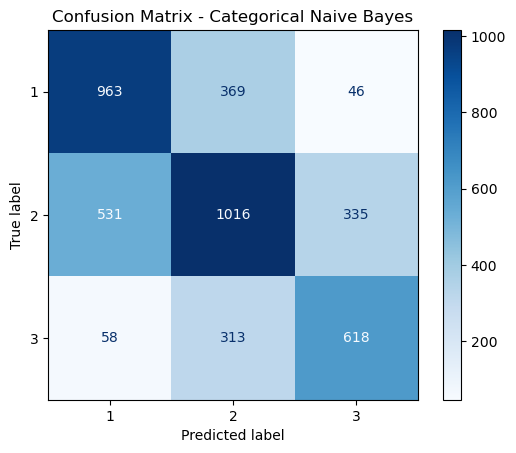

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predizioni CategoricalNB sullo stesso subset del KNN
X_test_cnb_sub = X_test_cnb[selected_columns]
y_pred_cnb = cnb.predict(X_test_cnb_sub)

# Confusion Matrix (calcolo automatico)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_cnb,
    cmap=plt.cm.Blues,
    values_format='d'
)

plt.title('Confusion Matrix - Categorical Naive Bayes')
plt.show()


Classi trovate in y_test: [1 2 3]
Shape y_test_bin: (4249, 3)
Shape y_score_cnb: (4249, 3)
Numero classi: 3


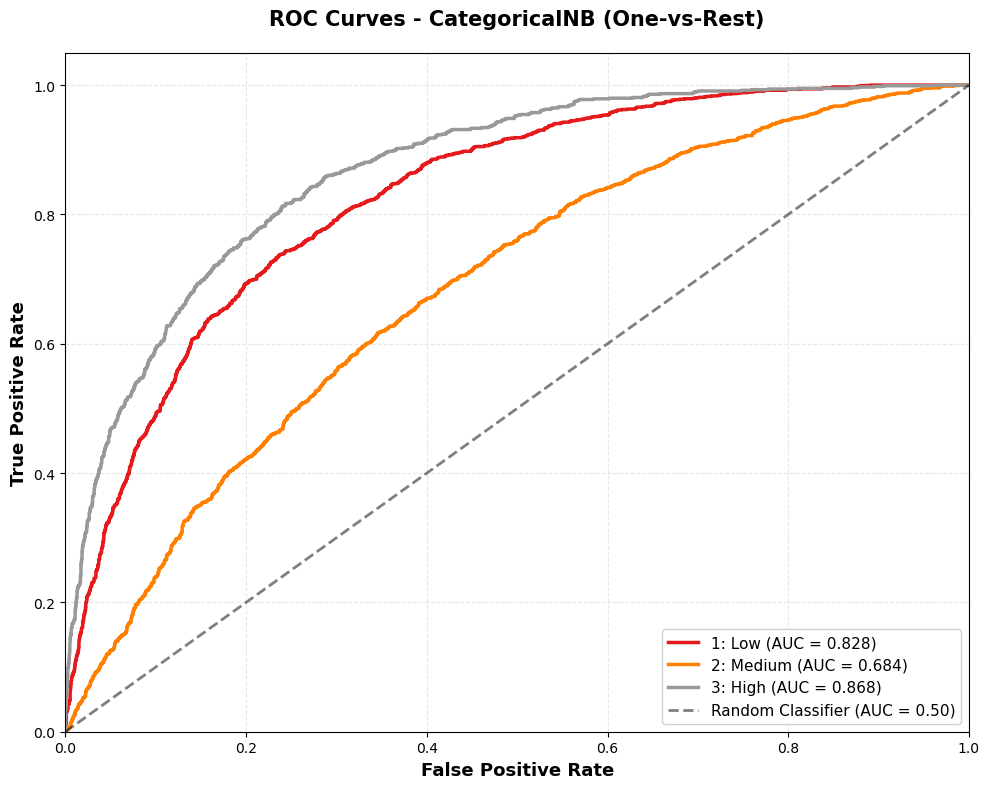


ROC AUC SCORES - CategoricalNB

📊 Overall Performance:
  Macro-average AUC:    0.7937
  Weighted-average AUC: 0.7739

📈 Per-class AUC:
  1: Low              : 0.8283
  2: Medium           : 0.6844
  3: High             : 0.8682


💡 Interpretazione:
  ⚠️  Discriminazione accettabile, ma migliorabile


In [28]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ══════════════════════════════════════════════════════════════
# ROC CURVE FOR MULTICLASS - One-vs-Rest approach
# ══════════════════════════════════════════════════════════════

# IMPORTANTE: Ottieni le classi REALI presenti nei tuoi dati
classes = np.unique(y_test)  # ← FIX: usa le classi effettive
print(f"Classi trovate in y_test: {classes}")

# Binarizza le etichette per l'approccio One-vs-Rest
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Se hai solo 2 classi, label_binarize restituisce shape (n, 1)
# Dobbiamo gestire questo caso
if n_classes == 2:
    # Per classificazione binaria, creiamo la seconda colonna (1 - prima colonna)
    y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])
    n_classes = 2

# Ottieni le probabilità predette
y_score_cnb = cnb.predict_proba(X_test_cnb)

# Verifica dimensioni
print(f"Shape y_test_bin: {y_test_bin.shape}")
print(f"Shape y_score_cnb: {y_score_cnb.shape}")
print(f"Numero classi: {n_classes}")

# ══════════════════════════════════════════════════════════════
# PLOT ROC CURVES - CategoricalNB
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 8))

# Colori dinamici in base al numero di classi
colors = plt.cm.Set1(np.linspace(0, 1, n_classes))

# Nomi delle classi dinamici
if n_classes == 3:
    class_names = ['1: Low', '2: Medium', '3: High']
else:
    class_names = [f'Class {c}' for c in classes]

# Plot ROC per ogni classe
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_cnb[:, i])
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, color=colors[i], lw=2.5,
            label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

# Linea diagonale (classificatore casuale)
ax.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, 
        label='Random Classifier (AUC = 0.50)')

# Formattazione
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
ax.set_title('ROC Curves - CategoricalNB (One-vs-Rest)', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(loc="lower right", fontsize=11, framealpha=0.9)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# CALCULATE AUC SCORES
# ══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("ROC AUC SCORES - CategoricalNB")
print("="*70)

# Macro-average: media semplice delle AUC
auc_macro = roc_auc_score(y_test_bin, y_score_cnb, average='macro')

# Weighted-average: media pesata per numerosità classe
auc_weighted = roc_auc_score(y_test_bin, y_score_cnb, average='weighted')

print(f"\n📊 Overall Performance:")
print(f"  Macro-average AUC:    {auc_macro:.4f}")
print(f"  Weighted-average AUC: {auc_weighted:.4f}")

# AUC per singola classe
print(f"\n📈 Per-class AUC:")
for i in range(n_classes):
    auc_class = roc_auc_score(y_test_bin[:, i], y_score_cnb[:, i])
    print(f"  {class_names[i]:20s}: {auc_class:.4f}")

print("\n" + "="*70)

# ══════════════════════════════════════════════════════════════
# INTERPRETAZIONE
# ══════════════════════════════════════════════════════════════
print("\n💡 Interpretazione:")
if auc_macro > 0.9:
    print("  ✅ Eccellente discriminazione per tutte le classi")
elif auc_macro > 0.8:
    print("  ✅ Buona discriminazione generale")
elif auc_macro > 0.7:
    print("  ⚠️  Discriminazione accettabile, ma migliorabile")
else:
    print("  ❌ Discriminazione debole, considera altri modelli")

In [29]:
# Per CategorialNB, controlla overfitting
train_acc = accuracy_score(y_train, cnb.predict(X_train_cnb))
test_acc = accuracy_score(y_test, y_pred_cnb)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Overfitting Gap: {(train_acc - test_acc)*100:.2f}%")

Train Accuracy: 0.6151
Test Accuracy:  0.6112
Overfitting Gap: 0.39%


The Categorical Naive Bayes model achieved a test accuracy of 0.611 
with an overfitting gap of only 0.39%, demonstrating exceptional 
generalization capability. 

# DECISION TREES


In [53]:
# ══════════════════════════════════════════════════════════════
# DECISION TREE - usa dataset NON normalizzato
# ══════════════════════════════════════════════════════════════

# Usa le stesse feature del KNN (ma senza scaling)
selected_columns = num_features + bin_features  # tutte le 22 feature

X_train_dt = X_train[selected_columns]
X_test_dt = X_test[selected_columns]

print("✅ Dataset preparato per Decision Tree (NON normalizzato)")
print(f"Shape train: {X_train_dt.shape}")
print(f"Shape test:  {X_test_dt.shape}")


✅ Dataset preparato per Decision Tree (NON normalizzato)
Shape train: (16995, 22)
Shape test:  (4249, 22)


In [54]:
# Diagnosi da fare:
# 1. Feature overlap tra classi?
print("========= Come cambia GameWeight tra le classi 1, 2 e 3? =========")
print(X_train_dt.groupby(y_train)['GameWeight'].describe())
print()

# 2. Class imbalance?
print("========= Class imbalance =========")
print(y_train.value_counts(normalize=True))



========= Come cambia GameWeight tra le classi 1, 2 e 3? =========
         count      mean       std  min     25%  50%     75%     max
Rating                                                              
1       5513.0  1.611724  0.597735  1.0  1.1094  1.5  2.0000  5.0000
2       7526.0  2.029349  0.709595  1.0  1.5000  2.0  2.5000  4.8537
3       3956.0  2.641892  0.793354  1.0  2.0000  2.6  3.1765  4.8889

========= Class imbalance =========
Rating
2    0.442836
1    0.324390
3    0.232774
Name: proportion, dtype: float64


- Analizzando come il peso dei giochi cambia tra le classi 1, 2 e 3: le medie sono troppo vicine e c'è un enorme sovrapposizione: valore massimo della classe 1 (5.0) e quello della classe 3 (4.88) ==> Significa che esistono giochi "Low Rating" che sono complessi quanto i "High Rating".  
Conseguenza: L'albero decisionale non può tracciare una linea netta (es. "se il peso è > 2 allora è Classe 2") perché troverebbe migliaia di errori in entrambi i lati.

- La Classe 2 domina. Il rischio: Se il modello è incerto su un gioco, tenderà a scommettere sulla Classe 2 semplicemente perché statisticamente ha più probabilità di indovinare.  
Conseguenza: Ecco perché nel tuo classification report la Classe 2 ha la recall più alta (0.73) ma la precision più bassa (0.59): il modello la spara ovunque, indovinando molti casi reali ma facendo anche molti falsi positivi.

### Baseline model (addestrato un primo albero "a mano" con parametri standard (max_depth=10, ecc.)

In [55]:
dt_baseline = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42
)
dt_baseline.fit(X_train_dt, y_train)
y_pred_baseline = dt_baseline.predict(X_test_dt)

print("\n" + "="*60)
print("🌳 BASELINE DECISION TREE")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))


🌳 BASELINE DECISION TREE
Accuracy: 0.6444

Classification Report:
              precision    recall  f1-score   support

           1       0.67      0.62      0.64      1378
           2       0.59      0.70      0.64      1882
           3       0.74      0.58      0.65       989

    accuracy                           0.64      4249
   macro avg       0.67      0.63      0.65      4249
weighted avg       0.65      0.64      0.64      4249



### Grid Search  
Ho creato un dizionario (param_grid) con 512 combinazioni possibili di parametri (Gini vs Entropy, diverse profondità, ecc.).  
Cross-Validation (CV=5): Invece di fidarsi di un solo test, il codice ha diviso il training set in 5 parti. Per ogni combinazione, ha addestrato il modello 5 volte, usando ogni volta una parte diversa come "mini-test". Questo garantisce che i parametri scelti funzionino bene in generale e non per pura fortuna.  

Il "Vincitore": Alla fine di 2560 addestramenti (512 combinazioni * 5 fold), il sistema ha eletto la combinazione migliore: Gini, Profondità 15, ccp_alpha 0.0005.

In [56]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20],  # ❌ Rimosso None
    'min_samples_split': [2, 10, 30, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'ccp_alpha': [0.0, 0.0001, 0.0005, 0.001]  # ✅ AGGIUNTO
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # ✅ Usa tutti i core
)

grid_search.fit(X_train_dt, y_train)

print("\n" + "="*60)
print("🔍 GRID SEARCH RESULTS")
print("="*60)
print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Valuta sul test set
dt_optimized = grid_search.best_estimator_
y_pred_optimized = dt_optimized.predict(X_test_dt)

print(f"\n🎯 Test Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimized))



Fitting 5 folds for each of 512 candidates, totalling 2560 fits


/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



🔍 GRID SEARCH RESULTS
Best Parameters: {'ccp_alpha': 0.0005, 'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.6451

🎯 Test Accuracy: 0.6489

Classification Report:
              precision    recall  f1-score   support

           1       0.72      0.59      0.65      1378
           2       0.59      0.73      0.65      1882
           3       0.73      0.57      0.64       989

    accuracy                           0.65      4249
   macro avg       0.68      0.63      0.65      4249
weighted avg       0.66      0.65      0.65      4249



### Randomized search  
==> metodo di ottimizzazione degli iperparametri che, invece di testare ogni singola combinazione possibile, ne seleziona un numero prefissato in modo casuale.

In [57]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Definizione dello spazio di ricerca (distribuzioni)
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': randint(2, 50),
    'min_samples_leaf': randint(1, 20),
    'ccp_alpha': uniform(0, 0.002) 
}

# 2. Inizializzazione ed esecuzione Randomized Search
print("🚀 Avvio Randomized Search (100 iterazioni)...")
random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=100,
    cv=5, 
    scoring='accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_dt, y_train)

# 3. Estrazione del miglior modello
dt_random_optimized = random_search.best_estimator_
y_pred_random = dt_random_optimized.predict(X_test_dt)

# 4. REPORT COMPLETO DEI RISULTATI
print("\n" + "="*60)
print("🌳 RANDOMIZED SEARCH - FINAL RESULTS")
print("="*60)
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV Score:    {random_search.best_score_:.4f}")
print(f"Test Accuracy:    {accuracy_score(y_test, y_pred_random):.4f}")

print("\nDetailed Classification Report:")
# Target names basati sulle tue classi 1, 2, 3
print(classification_report(y_test, y_pred_random, target_names=['1: Low', '2: Medium', '3: High']))

# # 5. Visualizzazione Matrice di Confusione
# fig, ax = plt.subplots(figsize=(8, 6))
# ConfusionMatrixDisplay.from_estimator(
#     dt_random_optimized, 
#     X_test_dt, 
#     y_test, 
#     display_labels=['Low', 'Medium', 'High'],
#     cmap=plt.cm.Greens, # Colore diverso per distinguerlo dalla Grid Search
#     normalize='true'
# )
# plt.title('Normalized Confusion Matrix - Randomized Search')
# plt.show()

🚀 Avvio Randomized Search (100 iterazioni)...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

🌳 RANDOMIZED SEARCH - FINAL RESULTS
Best Parameters: {'ccp_alpha': 0.00034658864014169155, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 16, 'min_samples_split': 26}
Best CV Score:    0.6452
Test Accuracy:    0.6507

Detailed Classification Report:
              precision    recall  f1-score   support

      1: Low       0.68      0.65      0.67      1378
   2: Medium       0.60      0.69      0.64      1882
     3: High       0.73      0.58      0.65       989

    accuracy                           0.65      4249
   macro avg       0.67      0.64      0.65      4249
weighted avg       0.66      0.65      0.65      4249




📊 FINAL MULTI-MODEL COMPARISON
                Model Strategy  Accuracy Improvement vs Baseline
             Baseline (Manual)  0.644387                   0.00%
      Grid Search (Exhaustive)  0.648859                  +0.45%
Randomized Search (Stochastic)  0.650741                  +0.64%


/var/folders/74/y5jc45jd04b_8s_25mz9p6140000gp/T/ipykernel_3536/616157584.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model Strategy", data=df_comparison, palette="viridis")


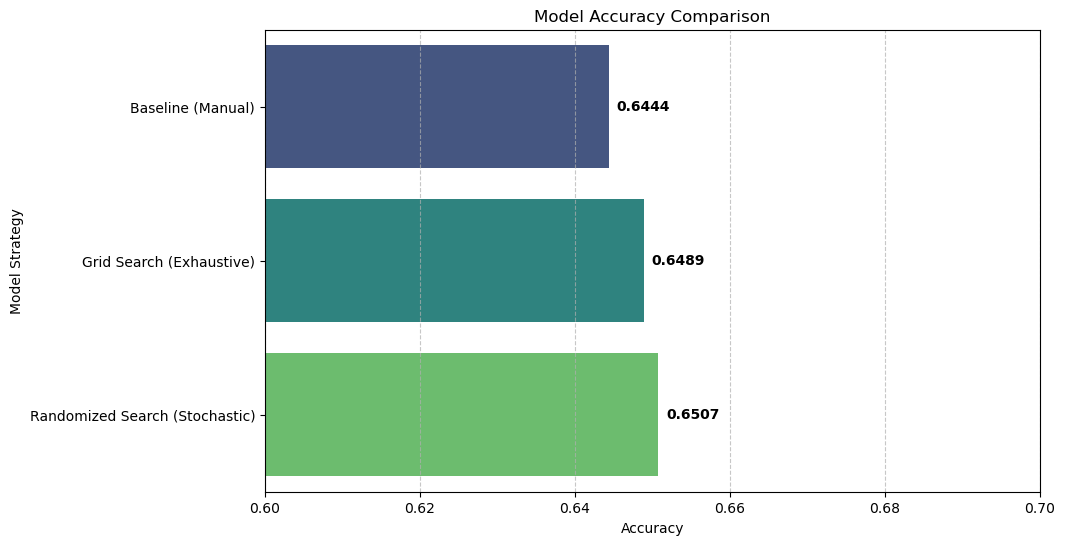

In [58]:
# Assicurati di aver eseguito prima i blocchi di Baseline, Grid Search e Randomized Search

print("\n" + "="*60)
print("📊 FINAL MULTI-MODEL COMPARISON")
print("="*60)

# Calcolo accuratezze
acc_baseline = accuracy_score(y_test, y_pred_baseline)
acc_grid     = accuracy_score(y_test, y_pred_optimized)
acc_random   = accuracy_score(y_test, y_pred_random)

# Creazione tabella comparativa
comparison_data = {
    "Model Strategy": ["Baseline (Manual)", "Grid Search (Exhaustive)", "Randomized Search (Stochastic)"],
    "Accuracy": [acc_baseline, acc_grid, acc_random],
    "Improvement vs Baseline": [
        "0.00%", 
        f"{(acc_grid - acc_baseline)*100:+.2f}%", 
        f"{(acc_random - acc_baseline)*100:+.2f}%"
    ]
}

import pandas as pd
df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

print("="*60)

# Visualizzazione grafica del confronto
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Model Strategy", data=df_comparison, palette="viridis")
plt.xlim(0.60, 0.70) # Zoom per evidenziare le differenze (regola in base ai tuoi risultati)
plt.title("Model Accuracy Comparison")
plt.grid(axis='x', linestyle='--', alpha=0.7)
for i, v in enumerate(df_comparison["Accuracy"]):
    plt.text(v + 0.001, i, f"{v:.4f}", color='black', va='center', fontweight='bold')
plt.show()

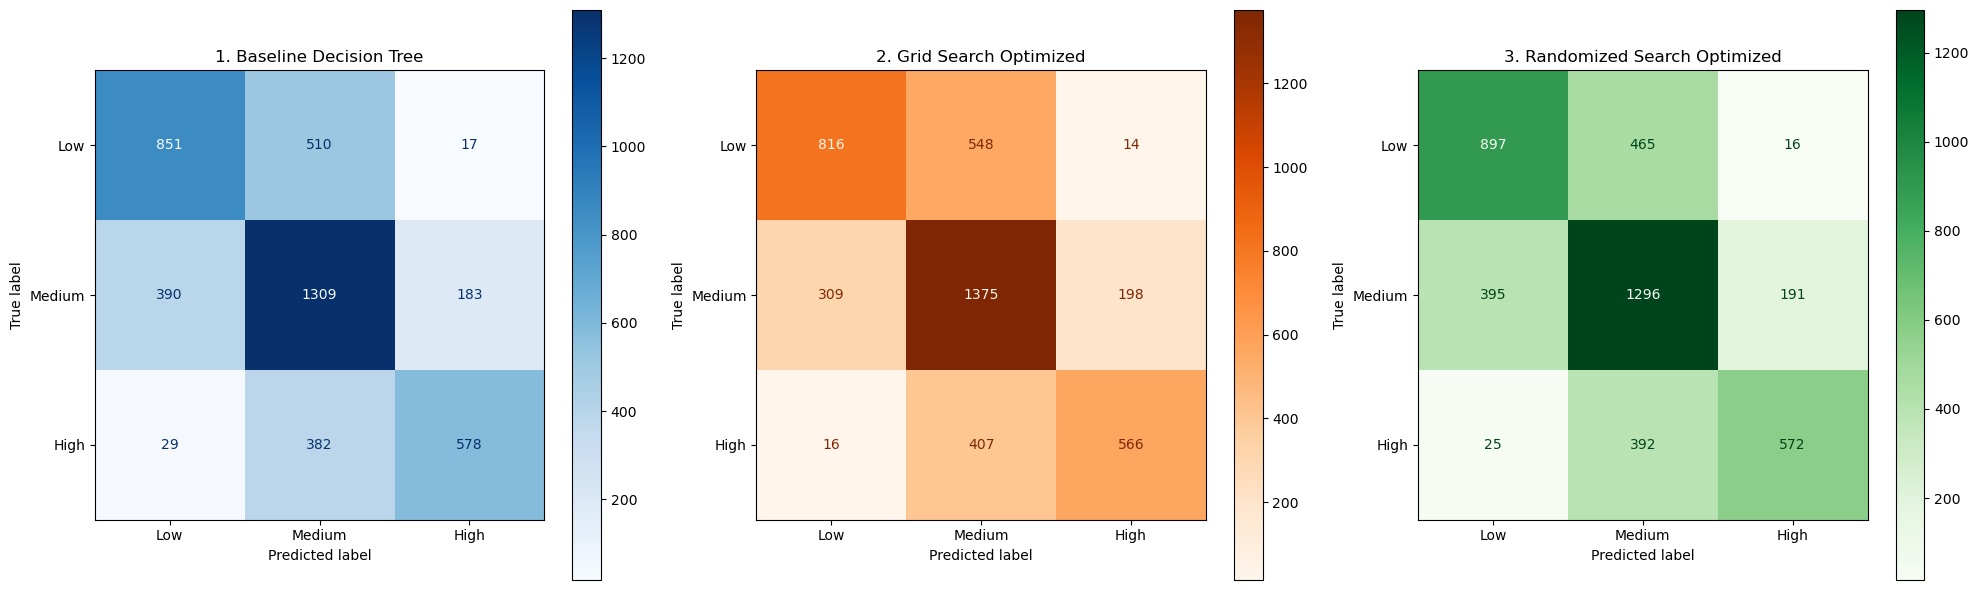

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Creiamo una figura con 3 sotto-grafici (uno per ogni modello)
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# 1. Matrice di Confusione - BASELINE
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline, 
    display_labels=['Low', 'Medium', 'High'],
    cmap=plt.cm.Blues, 
    normalize=None, # Mostra le percentuali (più facile da confrontare)
    ax=ax[0]
)
ax[0].set_title('1. Baseline Decision Tree')

# 2. Matrice di Confusione - GRID SEARCH
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_optimized, 
    display_labels=['Low', 'Medium', 'High'],
    cmap=plt.cm.Oranges, 
    normalize=None,
    ax=ax[1]
)
ax[1].set_title('2. Grid Search Optimized')

# 3. Matrice di Confusione - RANDOMIZED SEARCH
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_random, 
    display_labels=['Low', 'Medium', 'High'],
    cmap=plt.cm.Greens, 
    normalize=None,
    ax=ax[2]
)
ax[2].set_title('3. Randomized Search Optimized')

plt.tight_layout()
plt.show()

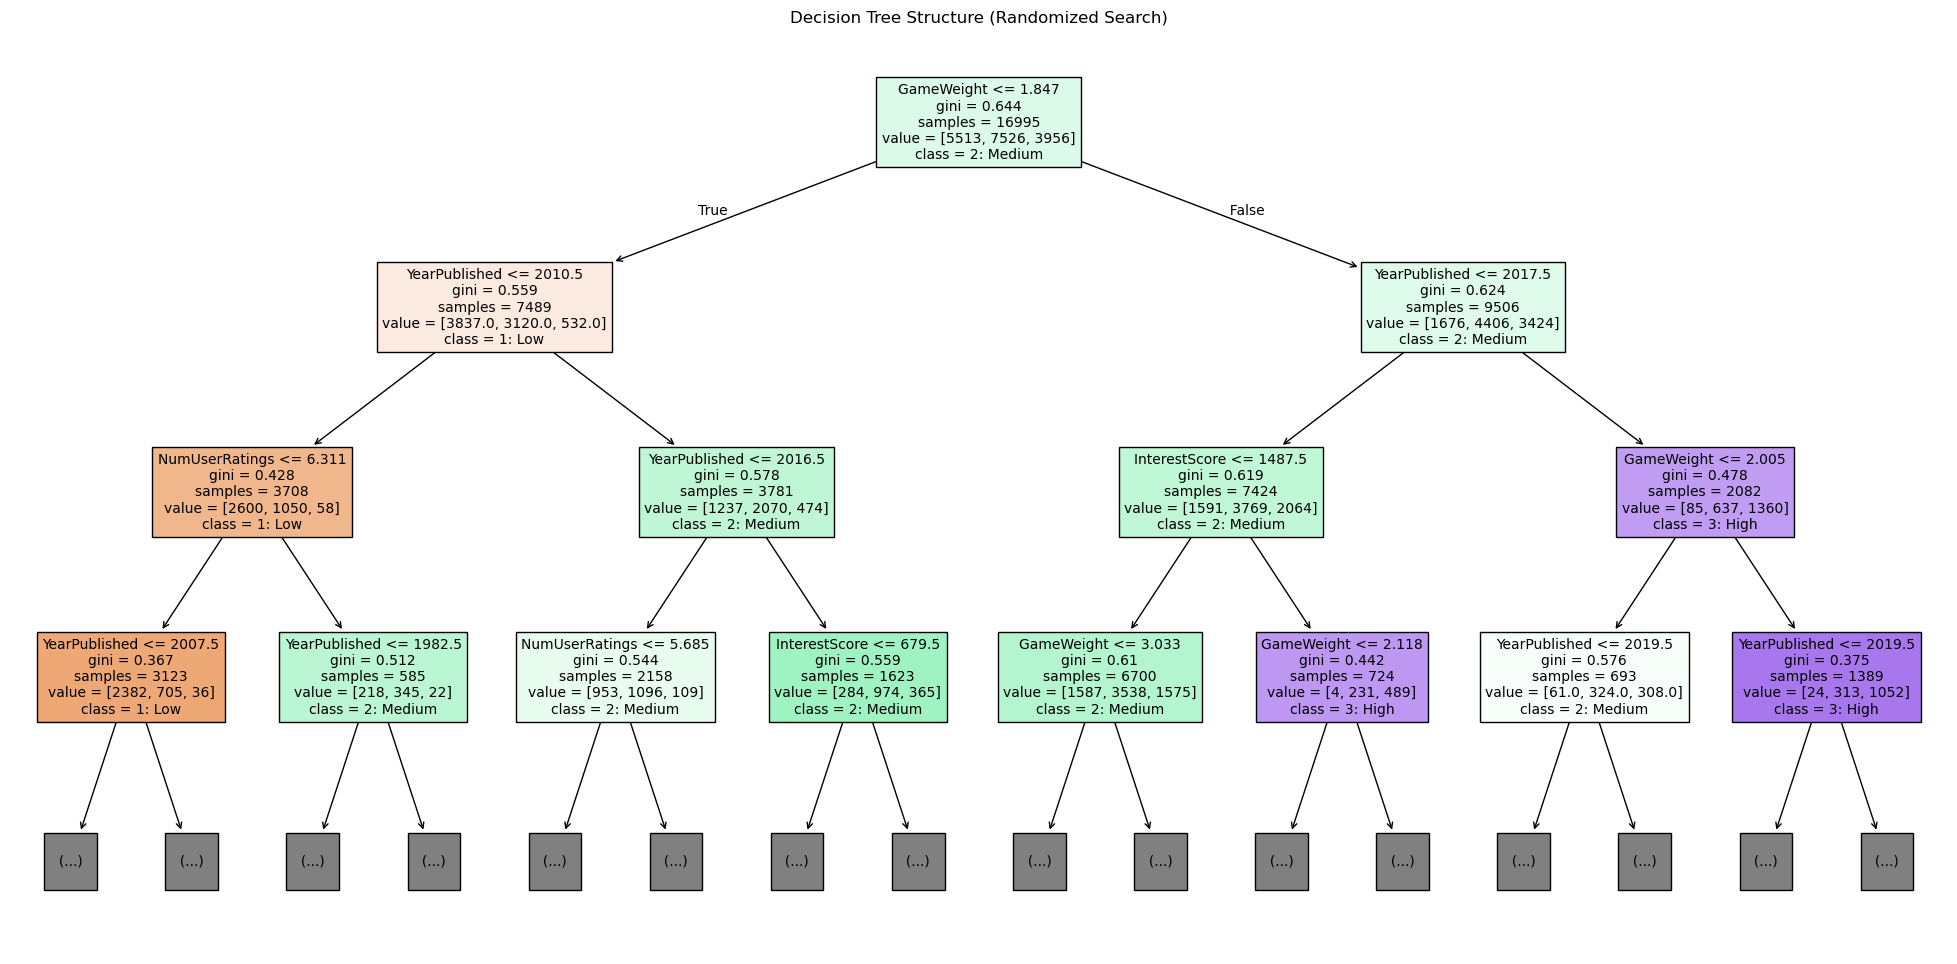

In [60]:
from sklearn.tree import plot_tree
plt.figure(figsize=(25, 12))

# Visualizziamo i primi 3 livelli per renderlo leggibile nel report
plot_tree(dt_random_optimized, 
          feature_names=selected_columns, 
          class_names=['1: Low', '2: Medium', '3: High'], 
          filled=True, 
          max_depth=3, # Limitiamo la profondità solo per la visualizzazione
          fontsize=10)

plt.title("Decision Tree Structure (Randomized Search)")
plt.show()

### applicando Grid Search, Random Search e facendo un confronto di queste con il baseline, quello che ha ottenuto una performance migliore è Random Search con i seguenti parametri:  
- 'ccp_alpha': 0.00034658864014169155, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 16, 'min_samples_split': 26


### Feature Importance


📊 FEATURE IMPORTANCE - Randomized Search Model
GameWeight               : 0.3526
YearPublished            : 0.3394
PlaytimeComAvg           : 0.0052
ComAgeRec                : 0.0044
InterestScore            : 0.0808
MinPlayers               : 0.0020
MaxPlayers               : 0.0205
NumUserRatings           : 0.1009
NumWeightVotes           : 0.0401
NumExpansions            : 0.0130
NumAlternates            : 0.0000
NumImplementations       : 0.0040
IsReimplementation       : 0.0000
Kickstarted              : 0.0000
Cat:Strategy             : 0.0000
Cat:War                  : 0.0354
Cat:Thematic             : 0.0000
Cat:Family               : 0.0000
Cat:CGS                  : 0.0018
Cat:Abstract             : 0.0000
Cat:Party                : 0.0000
Cat:Childrens            : 0.0000


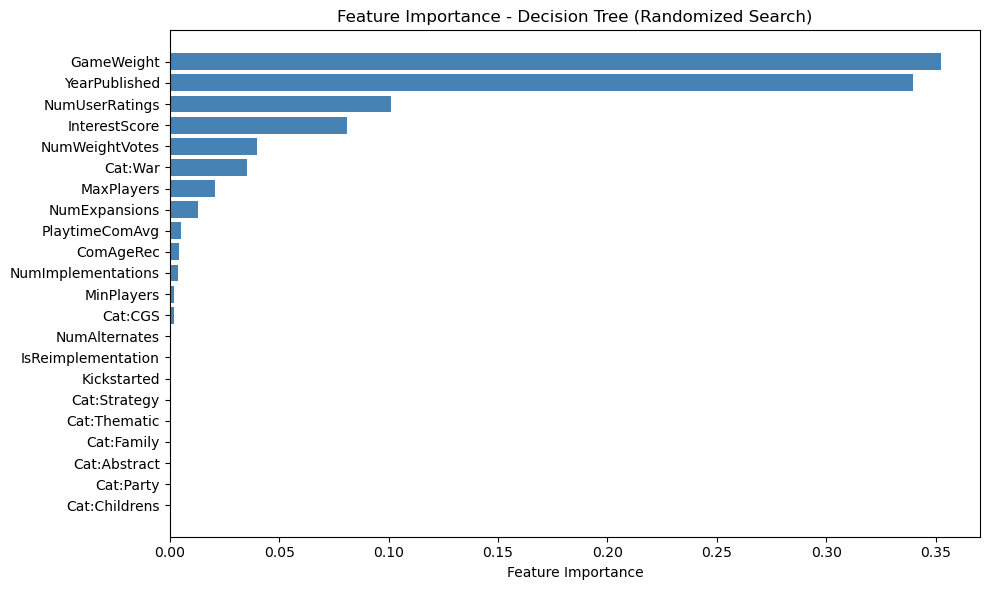


🏆 Top 5 Most Important Features:
       Feature  Importance
    GameWeight    0.352581
 YearPublished    0.339424
NumUserRatings    0.100949
 InterestScore    0.080835
NumWeightVotes    0.040064


In [61]:
# Feature Importance del modello ottimizzato con Randomized Search
importances = dt_random_optimized.feature_importances_  # Nota: è feature_importances_ (plurale con underscore)
feature_names = X_train_dt.columns

# Visualizzare
print("\n" + "="*60)
print("📊 FEATURE IMPORTANCE - Randomized Search Model")
print("="*60)
for name, imp in zip(feature_names, importances):
    print(f"{name:25s}: {imp:.4f}")
print("="*60)

# Visualizzazione grafica (opzionale ma consigliata)
import pandas as pd
import matplotlib.pyplot as plt

# Creare DataFrame per ordinare le feature
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance - Decision Tree (Randomized Search)')
plt.gca().invert_yaxis()  # Feature più importante in alto
plt.tight_layout()
plt.show()

# Stampare le top 5 feature
print("\n🏆 Top 5 Most Important Features:")
print(feature_imp_df.head().to_string(index=False))

In [62]:
# Dopo ogni modello
train_acc = accuracy_score(y_train, dt_random_optimized.predict(X_train_dt))
test_acc = accuracy_score(y_test, y_pred_random)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Overfitting Gap: {(train_acc - test_acc)*100:.2f}%")

Train Accuracy: 0.6780
Test Accuracy:  0.6507
Overfitting Gap: 2.73%


2.73% di gap = OVERFITTING MINIMO ✅  
The model achieved a test accuracy of 0.651 and a macro-averaged F1-score 
of [X], with minimal overfitting (training-test gap of only 2.73%), 
indicating strong generalization capabilities.